In [11]:
import numpy as np
import matplotlib.pyplot as plt

#Import utils.py from src directory, containing shared functions
import sys
sys.path.append('../src/')

In [12]:
import utils
import importlib
importlib.reload(utils)

<module 'utils' from '/mnt/windows/Linux_Wind_Shared/GalaxyFormation_FullProject/Notebooks/../src/utils.py'>

In [13]:
h = 0.67 #Hubble parameter factor: H0 = 100 * h km/s/Mpc

Om_m = 0.315            # matter density
Om_b = 0.022/(h*h)      # baryonic matter density
Om_lambda = 0.685       # vacuum energy density

rho_c = 2.78e11 *h*h    # in units of M_s/Mpc^3

"""
Defining constants for abundance calculation using PS formalism
"""

# mean matter density of the universe
rho_0 = Om_m * rho_c    # in units of M_s/Mpc^3
delta_c = 1.686         # Critical density for spherical collapse

# for normalising the power spectrum
sigma8_obs = 0.811      # Observed value of sigma_8
n = 0.965               # power spectrum P(k)~ k^n

# Halo Abundance Calculation
## Density Perturbation Standard-Deviation Calculation

In [14]:
# FT of the top-hat window function
def W(k,R):
    kR = k*R
    return 3*(np.sin(kR) - kR*np.cos(kR))/(kR**3)

In [15]:
def P(k,z,cutoff=np.inf): #Power spectrum evolution
    if k<=cutoff:    
        return Pi(k)*(T(k)*D(z))**2
    else:
        return 0

# Primordial power spectrum (un-normalised)
def Pi(k):
    return k**n

# Transfer Function
def T(k):
    Gamma = Om_m * h * np.exp( -Om_b* (1+np.sqrt(2*h)/Om_m) )
    q = k / (Gamma*h)
    value = 1 + (3.89*q) + (16.1*q)**2 + (5.46*q)**3 + (6.71*q)**4
    return np.log(1+2.34*q) / (2.34*q*value**(1/4))

# Growth factor, D(z) 
def D(z):
    Dz = (Om_m + 0.4545*Om_lambda) / (Om_m*(1+z)**3 + 0.4545*Om_lambda)
    return Dz**(1/3)

In [26]:
# Variance of smoothed density field (wrt radius, R)
def sigma_R(R,z=0,cutoff=1000):    
    # Integrand for the variance calculation
    def integral(k):
        return P(k,z,cutoff) * k**2 * W(k,R)**2 / (2 * np.pi ** 2)
    
    sigma2, _ = quad(integral, 0, np.inf, limit=500, epsabs=1e-5, epsrel=1e-5)
    return np.sqrt(sigma2)


# Variance of smoothed density field (wrt mass of region, M)
def sigma_M(M,z=0,cutoff=1000):
    # Compute R corresponding to the mass M
    R = (3 * M / (4 * np.pi * rho_0))**(1/3)
    
    return sigma_R(R,z,cutoff)

In [22]:
from scipy.integrate import quad

In [27]:
# Evaluate and print the normalization factor
R8 = 8/h      # units of Mpc

A = sigma8_obs/sigma_R(R8,0)
print(sigma_R(R8,0,np.inf))
print(f"Normalization factor A for sigma_8 = {sigma8_obs} is A = {A}")

0.00022314453983950192
Normalization factor A for sigma_8 = 0.811 is A = 3634.415615023862


In [28]:
M_range = np.logspace(6, 16, 500)  # Mass range in solar masses

y = [A*sigma_M(M,0,np.inf) for M in M_range]
y_1 = [A*sigma_M(M,0,1) for M in M_range]
y_10 = [A*sigma_M(M,0,10) for M in M_range]

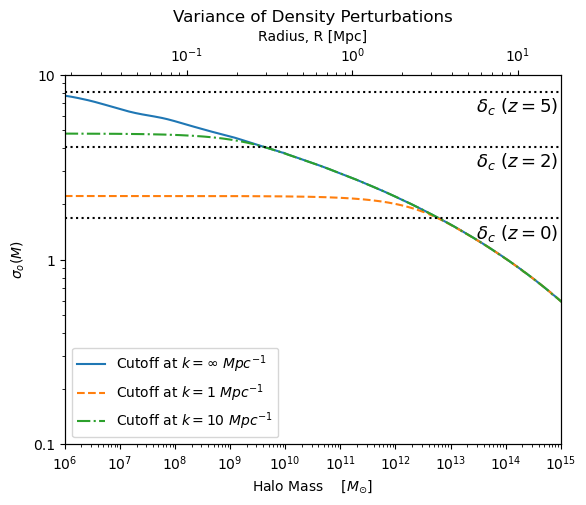

In [29]:
plt.figure()

plt.plot(M_range, y,label="Cutoff at $k = \infty \ Mpc^{-1}$")
plt.plot(M_range, y_1,label="Cutoff at $k = 1 \ Mpc^{-1}$", ls='--')
plt.plot(M_range, y_10,label="Cutoff at $k = 10 \ Mpc^{-1}$" , ls='-.')

plt.axhline(y=delta_c/D(z=0),ls=':',color='k')
plt.axhline(y=delta_c/D(z=2),ls=':',color='k')
plt.axhline(y=delta_c/D(z=5),ls=':',color='k')

plt.text(9e14,delta_c/D(z=0)-0.1, "$\delta_c \ (z=0)$", va='top',ha='right',fontsize=13)
plt.text(9e14,delta_c/D(z=2)-0.2, "$\delta_c \ (z=2)$", va='top',ha='right',fontsize=13)
plt.text(9e14,delta_c/D(z=5)-0.3, "$\delta_c \ (z=5)$", va='top',ha='right',fontsize=13)

plt.xscale('log')
plt.yscale('log')
plt.xlim(1e6,1e15)
# plt.ylim(1,10)

plt.xlabel("Halo Mass $\quad [M_{\odot}]$")
plt.ylabel("$\sigma_o(M)$")

plt.yticks([1e-1,1,1e1],["0.1",1,"10"])
plt.legend()

# Duplicate x-axis at the top
ax_top = plt.gca().twiny()                      # Get current axis and create a twin x-axis

ax_top.set_xlim(6,15)                           # Matching bottom axis range
R_range = [(3 * 10**M / (4 * np.pi * rho_0))**(1/3) for M in range(6,16)]
ax_top.set_xticks(R_range)
ax_top.set_xticklabels([f"{R}" for R in R_range])   
ax_top.set_xlabel("Radius, R [Mpc]")
ax_top.set_xscale('log')

# plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.title("Variance of Density Perturbations")

plt.show()

### Polynomial Fitting of Standard Deviation

Here we fit the standard deviation curve with a polynomial fitting function since the abundance calculation requires the derivative of the standard deviation (derivative of polynomial fitting function is easier to deal with that numerical differentiation).

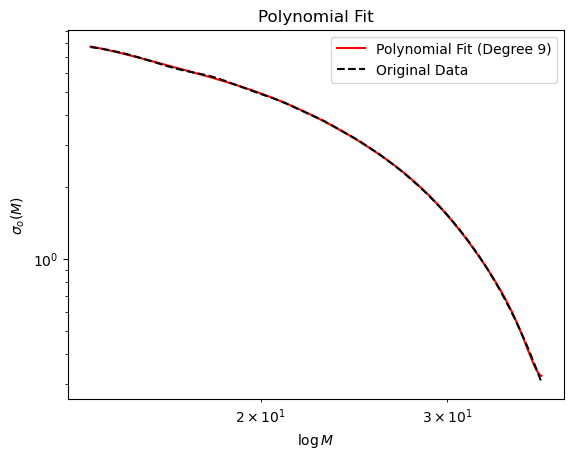

In [11]:
def poly_fit(x_arr,y_arr,degree,plot=0):
    # Perform polynomial fit
    coefficients = np.polyfit(x_arr, y_arr, degree)

    # Generate the fitted polynomial function
    polynomial = np.poly1d(coefficients)

    # Plot the original data and the fitted polynomial
    if (plot):
        plt.plot(x_arr, polynomial(x_arr), 'r', lw=1.5, label=f'Polynomial Fit (Degree {degree})')
        plt.plot(x_arr, y_arr, '--',color='k', label='Original Data')
        plt.xscale('log')
        plt.yscale('log')  
        plt.xlabel('$\log M$')
        plt.ylabel('$\sigma_o(M)$')
        plt.legend()
        plt.title('Polynomial Fit')
        plt.show()
    
    return coefficients

# arrays & degree for polynomial fitting
degree = 9
logM = np.log(M_range)
sigma_range = [A*sigma_M(M) for M in M_range]
cof = poly_fit(logM,sigma_range,degree,plot=True)

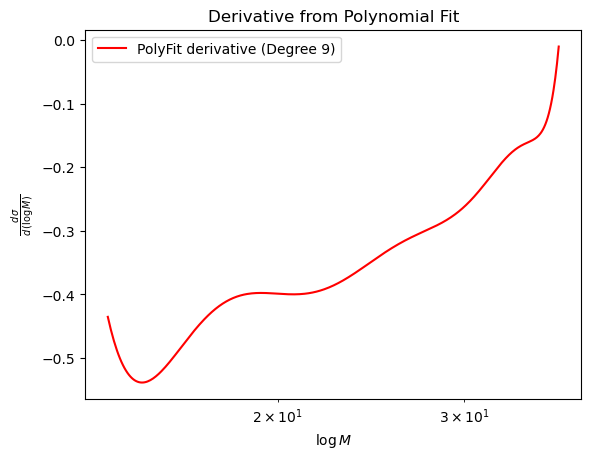

In [12]:
# Evaluating the derivative 
cof = poly_fit(logM,sigma_range,degree=9)
d_cof = np.polyder(cof)

fit_deriv = np.poly1d(d_cof)

# plotting the log-derivative
plt.plot(logM, fit_deriv(logM), 'r', lw=1.5, label=f'PolyFit derivative (Degree {degree})')
plt.xscale('log')
plt.xlabel(r'$\log M $')
plt.ylabel(r'$ \frac{d\,\sigma}{d\,(\log M)}$')
plt.legend()
plt.title('Derivative from Polynomial Fit')
plt.show()

In [13]:
# Press-Schechter mass function (gives RHS of above eqn)
def PS_MassFunc(M, z):
    # Generate the fitted polynomial function
    polynomial = np.poly1d(cof)
    sigma0 = polynomial(np.log(M))
    d_sigma = abs(fit_deriv(np.log(M)))
    factor = np.sqrt(2 / np.pi) * delta_c/(sigma0**2 * D(z)) * abs(fit_deriv(np.log(M)))
    exponent = (-delta_c**2 / (2 * sigma0**2 * D(z)**2))
    return factor * np.exp(exponent)

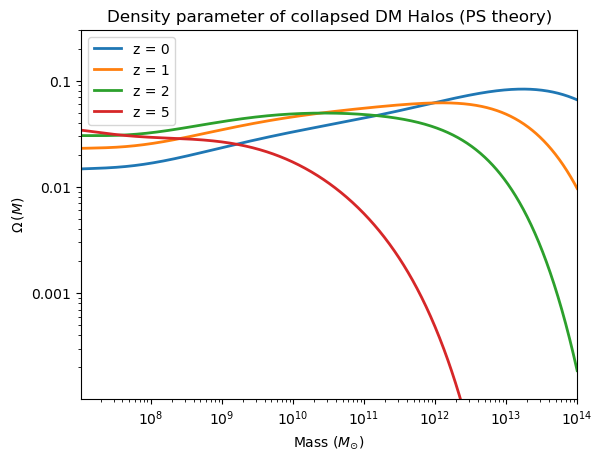

In [14]:
# Plotting fraction of critical density contributed by collapsed halo:
M_range = np.logspace(5, 14, 1000)  
redshifts = [0,1,2,5]

plt.figure()

for z in redshifts:
    density = [PS_MassFunc(M, z) for M in M_range]
    plt.plot(M_range, density, lw=2, label=f"z = {z}")
    
# Plotting density parameter
plt.xscale('log')
plt.yscale('log')
plt.xlim(1.05e7,1e14)
plt.ylim(1e-4,3e-1)

plt.xlabel("Mass $(M_{\odot})$")
plt.ylabel("$\Omega\,(M)$")
plt.title("Density parameter of collapsed DM Halos (PS theory)")
plt.yticks([0.001,0.01,0.1],['0.001','0.01','0.1'])
plt.legend()
plt.show()

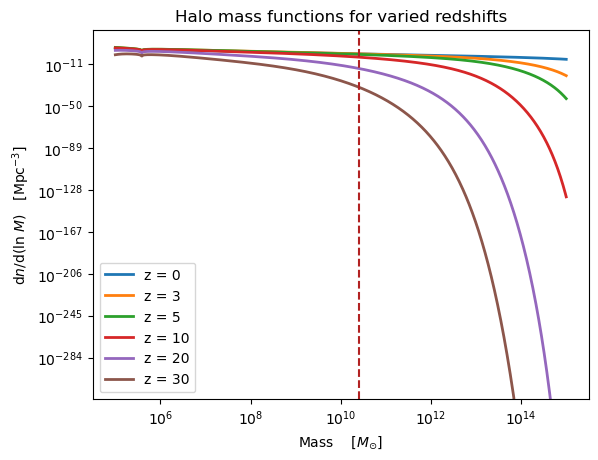

In [15]:
# Plotting abundance of DM halo, n(M,z):
M_range = np.logspace(5, 15, 1000)  
redshifts = [0,3, 5,10,20,30]

plt.figure()

for z in redshifts:
    dn_dlogM = [PS_MassFunc(M, z)*(rho_0/M) for M in M_range]
    plt.plot(M_range, dn_dlogM, lw=2 , label=f"z = {z}")
    
# Plotting mass fraction of halos
plt.xscale('log')
plt.yscale('log')
#plt.xlim(1e6,1e15)
#plt.ylim(1e-8,1e4)

plt.xlabel("Mass $\quad [M_{\odot}]$")
plt.ylabel("d$n/$d$(\ln\,M) \quad $[Mpc$^{-3}$]")
plt.title("Halo mass functions for varied redshifts")

plt.axvline(2.5 * 10**(10), color = r'firebrick', ls = '--')

plt.legend()
plt.show()

# Our SFRD Model Generation

In [16]:
from numba import jit

In [17]:
f_b = Om_b/Om_m     # fraction of baryonic matter
H0 = h/9.78e9         # in units of 1/yr

@jit(nopython=True)
def H(z): #in km/yr*km
    return H0 * np.sqrt( Om_m*(1+z)**3 + Om_lambda )

In [18]:
z_range = np.linspace(0.1,20, 100) #Main z array used throughout all code files

# plotting the fitted SFR densities (Literature SFRD models)
Madau_fit = [0.01 * (1+z)**2.6 / ( 1+((1+z)/3.2)**6.2 )    for z in z_range] #Madau and Fragos, 2017
Harikane_fit = [ 1 / ( 61.7 * (1+z)**(-3.13) + 10**(0.22*(1+z)) + 2.4 * 10**(0.5*(1+z)-3) ) for z in z_range] #Harikane, et al., 2022


# plotting error bars from:
# Harikane_2023
x1 = [9, 12, 16, 10, 14]
y1 = [-2.61, -3.23, -3.59, -3.38, -3.32]
y1_error = [ [0.16, 0.27, 2.83, 0.39, 0.47],[0.18, 0.29, 0.33, 0.38, 0.29] ] 

# Bhatawdekar_2019
x2 = [6, 7, 8, 9]
y2 = [-1.69, -1.76, -1.9, -1.97]
y2_error = [[0.07, 0.08, 0.09, 0.13],[0.08, 0.08, 0.1, 0.14]] 

# Bouwens_2023
x3 = [8, 10, 12.9]
y3 = [-2.94, -3.46, -3.76]
y3_error = [[0.28, 0.14, 0.27],[0.28, 0.14, 0.23]]

## Feedback Processes (SN and AGN)

In [19]:
# Suppressing Star formation efficiency (SN & AGN feedback)
def get_epsilon(z, M, V_crit, M_crit):       # V_crit in units of km/s
    M_c = (V_crit/23.4)**3  * 10**1.5 / np.sqrt(Om_m*(1+z)**3 + Om_lambda) * 1e8/ h 
    supp_SN = M**3/ (M**3 + M_c**3) # np.tanh(0.9*M/M_c)**2
    supp_AGN = 1 / np.sqrt(1+(M/M_crit))
    return supp_SN * supp_AGN

In [20]:
# Total SFR with Suppression by Simpsons method
def SFR_withSupp(z, M_min, M_max, eff=0.01, Vc=100,Mc=1e12):
    constants = eff * f_b / 0.06 
    # Integrand for the SFR density calculation
    def f(M):
        return constants * PS_MassFunc(M, z)*(rho_0/M) * H(z) * get_epsilon(z,M,Vc,Mc)
    a,b = M_min,M_min
    I = 0
    while b<M_max:
        b = 1.01*a
        I = I + (b-a)*(f(a) + 4*f((a+b)/2) + f(b))/6
        a = b
    return I  

In [21]:
# Adjustable parameters
epsilon_0 = 0.02
epsilon_02 = 0.05
M_u = 1e15
M_l = 1e5

"""
The following lines generate the SFRD data for various parameters. These take a long time to run and so should only be run once initially
(and then commented out). The following cells should be used to save the generated data in .csv format and to load them directly from these
.csv files.
"""

#SFRs = [ SFR_withSupp(z, M_l, M_u, eff=epsilon_0, Vc=100) for z in z_range] 
#SFR1s = [ SFR_withSupp(z, M_l, M_u, eff=epsilon_0, Vc=75) for z in z_range] 
#SFR2s = [ SFR_withSupp(z, M_l, M_u, eff=epsilon_0, Vc=50) for z in z_range]

#SFRs_2 = [ SFR_withSupp(z, M_l, M_u, eff=epsilon_02, Vc=100) for z in z_range] 
#SFR1s_2 = [ SFR_withSupp(z, M_l, M_u, eff=epsilon_02, Vc=75) for z in z_range] 
#SFR2s_2 = [ SFR_withSupp(z, M_l, M_u, eff=epsilon_02, Vc=50) for z in z_range]

'\nThe following lines generate the SFRD data for various parameters. These take a long time to run and so should only be run once initially\n(and then commented out). The following cells should be used to save the generated data in .csv format and to load them directly from these\n.csv files.\n'

In [22]:
"""
In this cell, generated data from the previous cell is stored into .csv files in the "Data" folder in the parent directory.
"""

#Our_SFR_Data = np.column_stack((SFRs, SFR1s, SFR2s))

#np.savetxt("../Data/OurSFRsData.csv", Our_SFR_Data, delimiter = ",", header = "SFRs, SFR1s, SFR2s")

#Our_SFR_Data2 = np.column_stack((SFRs_2, SFR1s_2, SFR2s_2))

#np.savetxt("../Data/OurSFRsData2.csv", Our_SFR_Data2, delimiter = ",", header = "SFRs_2, SFR1s_2, SFR2s_2")

'\nIn this cell, generated data from the previous cell is stored into .csv files in the "Data" folder in the parent directory.\n'

In [23]:
SFRs, SFR1s, SFR2s = np.genfromtxt("../Data/OurSFRsData.csv", unpack = True, delimiter = ",", skip_header = 1)

In [24]:
SFRs_2, SFR1s_2, SFR2s_2 = np.genfromtxt("../Data/OurSFRsData2.csv", unpack = True, delimiter = ",", skip_header = 1)

In [25]:
from utils import New_SFR, Hopkin_SFRD #New_SFR refers to Khaire and Srianand, 2019; Hopkin_SFRD refers to Hopkins and Beacom, 2006

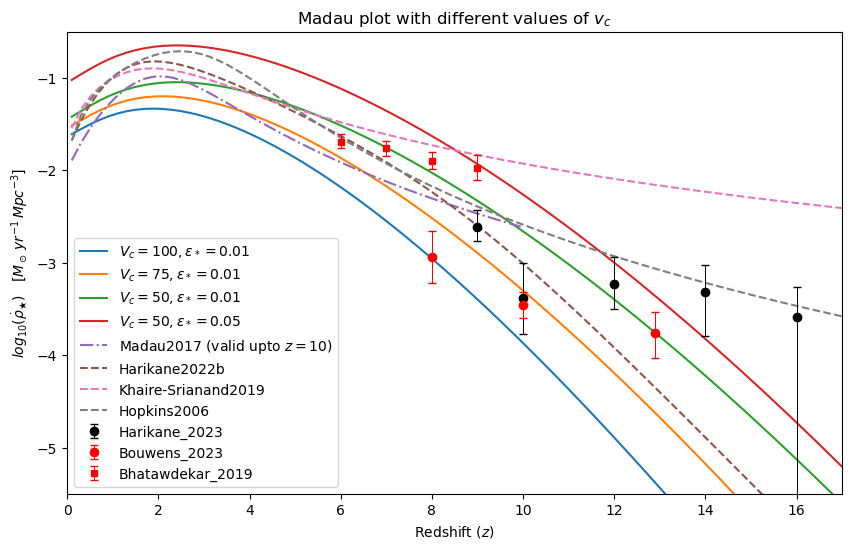

In [26]:
# Madau plot for each M-limits
plt.figure(figsize = (10, 6))
plt.plot(z_range, np.log10(SFRs), label=r"$V_c = 100,\epsilon_*=0.01$")
plt.plot(z_range, np.log10(SFR1s), label=r"$V_c = 75,\epsilon_*=0.01$")
plt.plot(z_range, np.log10(SFR2s), label=r"$V_c = 50,\epsilon_*=0.01$")
plt.plot(z_range, np.log10(SFR2s_2), label=r"$V_c = 50,\epsilon_*=0.05$")

# stopping Madau_fit (as its defined upto z=10)
mask = z_range <= 10    
z_range_m = z_range[mask]
Madau_fit = np.array(Madau_fit)
Madau_fit_m = Madau_fit[mask]

plt.plot(z_range_m, np.log10(Madau_fit_m),'-.', label="Madau2017 (valid upto $z =10$)")
plt.plot(z_range, np.log10(Harikane_fit),'--', label="Harikane2022b")
plt.plot(z_range, np.log10(New_SFR(z_range)),'--', label="Khaire-Srianand2019")
plt.plot(z_range, np.log10(Hopkin_SFRD(z_range)),'--', label="Hopkins2006")

# plotting error bars
plt.errorbar(x1,y1,yerr = y1_error, capsize=3, fmt='o', color='k', lw=0.7, label="Harikane_2023")
plt.errorbar(x3,y3,yerr = y3_error, capsize=3, fmt='o', color='r', lw=0.7, label="Bouwens_2023")
plt.errorbar(x2,y2,yerr = y2_error, capsize=3, fmt=' ', marker='s', ms=5, color='r', lw=0.7, label="Bhatawdekar_2019")
    
plt.xlim(0,17)
plt.ylim(-5.5,-0.5)
plt.xlabel("Redshift $(z)$")
plt.ylabel(r"$log_{10} (\dot{\rho}_\bigstar) \quad [M_\odot\, yr^{-1}\, Mpc^{-3}]$")
plt.title("Madau plot with different values of $v_c$")

plt.legend()
plt.show()

# Variation in Star Formation Efficiency

## SFE variation in $z$ without Dust Attenuation

In [27]:
#Redshift variation without dust attenuation
z_for_eff = np.array([2, 3, 4, 6, 7, 8, 9, 10, 12, 14])
epsilon_uncorrected = np.array([0.02, 0.02, 0.03, 0.03, 0.03, 0.04, 0.04, 0.04, 0.15, 0.23])

SFRs_uncorrected = [ SFR_withSupp(z_for_eff, M_l, M_u, epsilon_uncorrected, Vc=100)]
SFR1s_uncorrected = [ SFR_withSupp(z_for_eff, M_l, M_u, eff=epsilon_uncorrected, Vc=75)] 
SFR2s_uncorrected = [ SFR_withSupp(z_for_eff, M_l, M_u, eff=epsilon_uncorrected, Vc=50)]

Text(0, 0.5, '$log_{10}\\dot{\\rho}_*$')

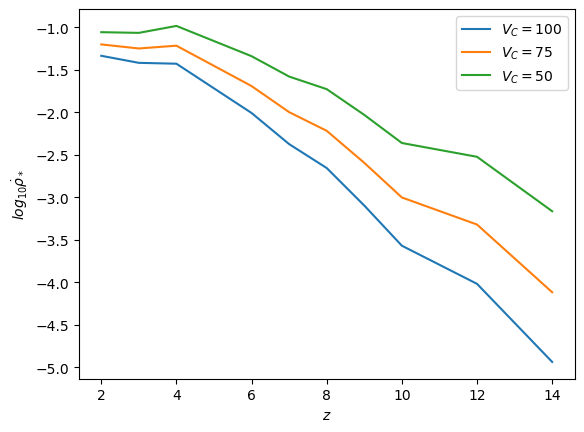

In [28]:
plt.plot(z_for_eff, np.log10(SFRs_uncorrected[0]), label = r'$V_C=100$')
plt.plot(z_for_eff, np.log10(SFR1s_uncorrected[0]), label = r'$V_C=75$')
plt.plot(z_for_eff, np.log10(SFR2s_uncorrected[0]), label = r'$V_C=50$')
plt.legend()
plt.xlabel(r'$z$')
plt.ylabel(r'$log_{10}\dot{\rho}_*$')

## SFE Variation with Dust Attenuation

In [29]:
#Redshift variation with dust attenuation
epsilon_corrected = np.array([0.1, 0.07, 0.05, 0.06, 0.05, 0.05, 0.044, 0.04, 0.19, 0.25])

SFRs_corrected = [ SFR_withSupp(z_for_eff, M_l, M_u, epsilon_corrected, Vc=100)]
SFR1s_corrected = [ SFR_withSupp(z_for_eff, M_l, M_u, eff=epsilon_corrected, Vc=75)] 
SFR2s_corrected = [ SFR_withSupp(z_for_eff, M_l, M_u, eff=epsilon_corrected, Vc=50)]

Text(0, 0.5, '$log_{10}\\dot{\\rho}_*$')

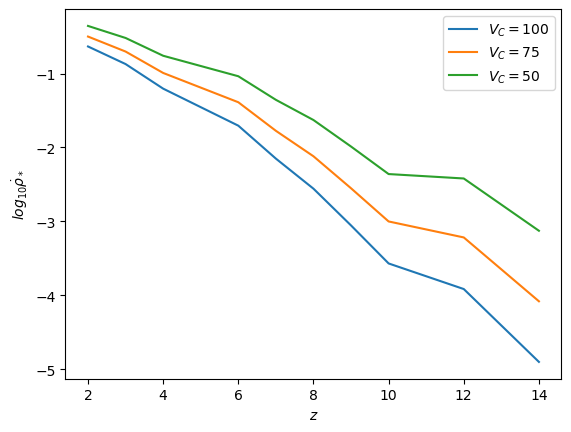

In [30]:
plt.plot(z_for_eff, np.log10(SFRs_corrected[0]), label = r'$V_C=100$')
plt.plot(z_for_eff, np.log10(SFR1s_corrected[0]), label = r'$V_C=75$')
plt.plot(z_for_eff, np.log10(SFR2s_corrected[0]), label = r'$V_C=50$')
plt.legend()
plt.xlabel(r'$z$')
plt.ylabel(r'$log_{10}\dot{\rho}_*$')